In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
ASSETS = [

    "^NSEI",
    "^NSEBANK",
    "GOLDBEES.NS",
    "LIQUIDBEES.NS"

]

START_DATE = "2010-01-01"
END_DATE = "2025-01-01"

In [3]:
prices = yf.download(

    ASSETS,

    start=START_DATE,

    end=END_DATE,

    auto_adjust=True

)["Close"]

prices = prices.dropna()

[*********************100%***********************]  4 of 4 completed


In [4]:
india_vix = yf.download(

    "^INDIAVIX",

    start=START_DATE,

    end=END_DATE,

    auto_adjust=True

)["Close"]

[*********************100%***********************]  1 of 1 completed


In [5]:
usdinr = yf.download(

    "INR=X",

    start=START_DATE,

    end=END_DATE,

    auto_adjust=True

)["Close"]

[*********************100%***********************]  1 of 1 completed


In [6]:
returns = prices.pct_change().dropna()


realized_vol = (

    returns.rolling(20).std()

    * np.sqrt(252)

)

momentum = prices.pct_change(20)

short_ma = prices.rolling(20).mean()
long_ma = prices.rolling(100).mean()

ma_spread = (short_ma - long_ma) / long_ma


rolling_mean = (

    returns.rolling(60).mean()

    * 252

)

rolling_vol = (

    returns.rolling(60).std()

    * np.sqrt(252)

)

rolling_sharpe = (

    rolling_mean / rolling_vol

)


nifty_gold_corr = (

    returns["^NSEI"]

    .rolling(60)

    .corr(returns["GOLDBEES.NS"])

)

nifty_bank_corr = (

    returns["^NSEI"]

    .rolling(60)

    .corr(returns["^NSEBANK"])

)




In [7]:

features = pd.concat([

    returns,

    realized_vol,

    momentum,

    ma_spread,

    rolling_sharpe,

    nifty_gold_corr.rename("NIFTY_GOLD_CORR"),

    nifty_bank_corr.rename("NIFTY_BANK_CORR"),

    india_vix.pct_change().squeeze().rename("INDIA_VIX"),

    usdinr.pct_change().squeeze().rename("USDINR")

], axis=1)

features = features.dropna()

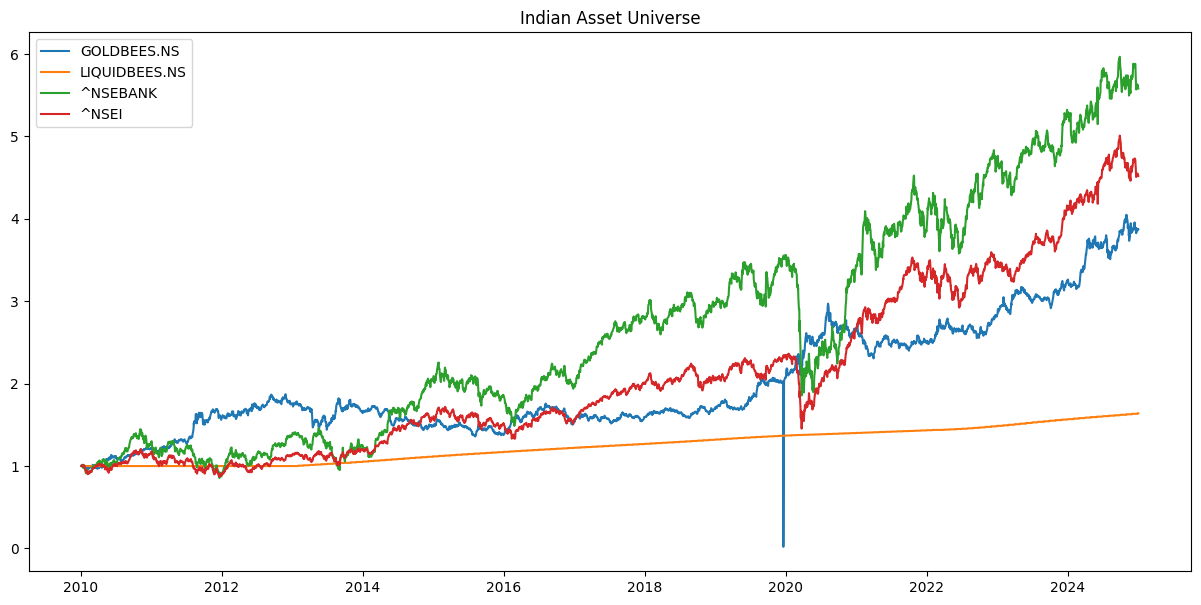

In [8]:
plt.figure(figsize=(15,7))

for asset in prices.columns:

    normalized = prices[asset] / prices[asset].iloc[0]

    plt.plot(

        normalized,

        label=asset

    )

plt.legend()

plt.title("Indian Asset Universe")

plt.show()

In [11]:
prices.to_csv(

    "../data/processed/prices.csv"

)

returns.to_csv(

    "../data/processed/returns.csv"

)

features.to_csv(

    "../data/processed/features.csv"

)

india_vix.to_csv(

    "../data/processed/india_vix.csv"

)

usdinr.to_csv(

    "../data/processed/usdinr.csv"

)
